In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv('data/df_features_with_label_standardised.csv')

# Ensure dates are in the correct format and sort them chronologically
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['date', 'symbol']).reset_index(drop=True)

In [3]:
# 2. Identify the columns to EXCLUDE from PCA (Identifiers + Targets)
# Notice now using 'label' and 'label_lead' based on the new dataset!
exclude_cols = ['date', 'symbol', 'label', 'label_lead']

In [5]:
# 3. Create our purely numeric Feature Matrix (X) and our Info Matrix
X = df.drop(columns=[col for col in exclude_cols if col in df.columns])
info_df = df[[col for col in exclude_cols if col in df.columns]] # Keep dates and labels safe

# Handle any missing/infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.ffill().bfill().fillna(0)

In [6]:
# 4. CHRONOLOGICAL SPLIT 
# We use the first 80% of data to train, and the last 20% to test
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

info_train = info_df.iloc[:split_index].reset_index(drop=True)
info_test = info_df.iloc[split_index:].reset_index(drop=True)

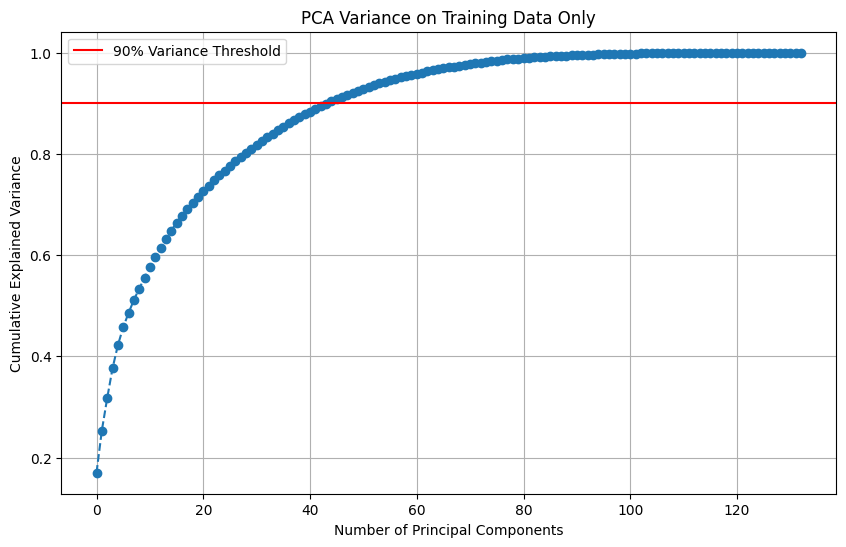

Saved plot to: data/outputs/pca_variance_plot.png


<Figure size 640x480 with 0 Axes>

In [11]:
# 5. Fit PCA ONLY on the Training Data!
pca = PCA()
pca.fit(X_train) 

# Plot to check variance (Optional but good for report)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance on Training Data Only')
plt.legend()
plt.grid(True)
plt.show()

plt.savefig('data/outputs/pca_variance_plot.png', bbox_inches='tight')
print("Saved plot to: data/outputs/pca_variance_plot.png")
plt.show()

In [9]:
# 6. Apply Final PCA (90% threshold)
pca_final = PCA(n_components=0.90)
# Fit and transform the train data
X_train_pca = pca_final.fit_transform(X_train)
# ONLY transform the test data using the rules learned from training!
X_test_pca = pca_final.transform(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"Number of PCA components kept: {X_train_pca.shape[1]}")

Original features: 133
Number of PCA components kept: 45


In [7]:
# 6. Reconstruct a new DataFrame with your PCA components
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

In [10]:
# 7. Reconstruct the Datasets
pca_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

# Put the training components into a DataFrame and re-attach dates/labels
df_train_pca = pd.DataFrame(X_train_pca, columns=pca_columns)
df_train_pca = pd.concat([info_train, df_train_pca], axis=1)

# Put the testing components into a DataFrame and re-attach dates/labels
df_test_pca = pd.DataFrame(X_test_pca, columns=pca_columns)
df_test_pca = pd.concat([info_test, df_test_pca], axis=1)

In [12]:
# 8. Save the outputs
df_train_pca.to_csv('data/pca_train_features.csv', index=False)
df_test_pca.to_csv('data/pca_test_features.csv', index=False)
print("Success! Saved datasets to: data/pca_train_features.csv and data/pca_test_features.csv")

Success! Saved datasets to: data/pca_train_features.csv and data/pca_test_features.csv
